# IMF AI Preparedness Index (AIPI) — Nepal, Income-Adjustment Test

**Source:** IMF DataMapper API (`AI_PI` indicator), cross-confirmed against World Bank 
Data360 (`IMF_AI_AIPI_IX`) — both return identical values. 165 economies with GDP 
matches, 2023 data (most recent available). Compiled by IMF from 8 underlying 
institutions: Fraser Institute, ILO, ITU, UN, UNCTAD, UPU, World Bank, WEF.

**Purpose:** AIPI's raw ranking placed Nepal last of 6 South Asian countries checked 
(below Pakistan). Before treating that as a finding, this notebook runs the same 
income-adjustment test used throughout this project — same logic as the Oxford, 
ITU, GII, and Findex notebooks. Result already known from manual computation: 
the raw ranking is a wealth-proxy artifact (r=0.855 with income, the strongest 
income-correlation of any source checked this session); income-adjusted, Nepal 
sits at the 51st percentile — exactly average, not a regional laggard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")
NEPAL = "NPL"

## 2. Merge with World Bank GDP, run income-adjustment test

In [6]:
GDP_FILE = next(RAW_DIR.glob("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))
GDP_META_FILE = next(RAW_DIR.glob("Metadata_Country_API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_*.csv"))

wb = pd.read_csv(GDP_FILE, skiprows=4)
wb_meta = pd.read_csv(GDP_META_FILE)
real_codes = set(wb_meta.loc[wb_meta["Region"].notna(), "Country Code"])
wb = wb[wb["Country Code"].isin(real_codes)]
year_cols = [c for c in wb.columns if c.isdigit()]

def latest_value(row):
    for y in sorted(year_cols, reverse=True):
        if pd.notna(row[y]):
            return row[y]
    return np.nan

wb["gdp"] = wb.apply(latest_value, axis=1)
gdp_map = dict(zip(wb["Country Code"], wb["gdp"]))

df = aipi_df.copy()
df["gdp"] = df["iso3"].map(gdp_map)
df = df.dropna(subset=["gdp"])
df["log_gdp"] = np.log(df["gdp"])
print(f"n = {len(df)}")

slope, intercept, r, p, se = stats.linregress(df["log_gdp"], df["aipi"])
df["resid"] = df["aipi"] - (slope * df["log_gdp"] + intercept)
df["raw_rank"] = df["aipi"].rank(ascending=False).astype(int)
df["adjusted_rank"] = df["resid"].rank(ascending=False).astype(int)

print(f"Income correlation: r={r:.3f}, p={p:.2e}")
nepal_resid = df.loc[df.iso3 == NEPAL, "resid"].iloc[0]
nepal_pct = stats.percentileofscore(df["resid"], nepal_resid)
print(f"Nepal residual = {nepal_resid:+.3f}, percentile = {nepal_pct:.1f}")

df.to_csv(PROCESSED_DIR / "aipi_income_adjusted.csv", index=False)

n = 165
Income correlation: r=0.855, p=2.31e-48
Nepal residual = -0.000, percentile = 50.9


## 3. South Asia comparison table — raw vs. income-adjusted

In [7]:
SOUTH_ASIA = ["NPL", "IND", "PAK", "BGD", "LKA", "BTN"]
NAMES = {"NPL": "Nepal", "IND": "India", "PAK": "Pakistan", "BGD": "Bangladesh", "LKA": "Sri Lanka", "BTN": "Bhutan"}

sa = df[df.iso3.isin(SOUTH_ASIA)].copy()
sa["Country"] = sa["iso3"].map(NAMES)
sa = sa[["Country", "gdp", "aipi", "raw_rank", "resid", "adjusted_rank"]].sort_values("resid", ascending=False)
sa.columns = ["Country", "GDP per capita (PPP)", "AIPI (raw)", "Raw rank (of 165)", "Income-adjusted residual", "Adjusted rank (of 165)"]

sa.to_csv(PROCESSED_DIR / "south_asia_aipi_comparison.csv", index=False)
with open(PROCESSED_DIR / "south_asia_aipi_comparison.md", "w") as f:
    f.write(sa.to_markdown(index=False))
sa

,Country,GDP per capita (PPP),AIPI (raw),Raw rank (of 165),Income-adjusted residual,Adjusted rank (of 165)
69,India,11747.916044,0.492503,71,0.069504,29
87,Pakistan,6573.416134,0.368638,119,0.010575,69
147,Nepal,6175.158972,0.350979,127,-0.000095,82
114,Bangladesh,10153.708379,0.384064,111,-0.022625,112
103,Sri Lanka,17065.029864,0.436067,91,-0.028686,117
116,Bhutan,19594.002838,0.441917,89,-0.038290,124


## 4. Figure — slope chart: raw rank vs. income-adjusted rank

The chart this finding deserves: shows each country's position shifting once 
income is controlled for. Nepal's raw rank (worst in the group) moves 
dramatically toward the middle once adjusted — the visual proof that the raw 
ranking was a wealth-proxy artifact. A new chart type for this project — 
paired-rank comparison, not used before.

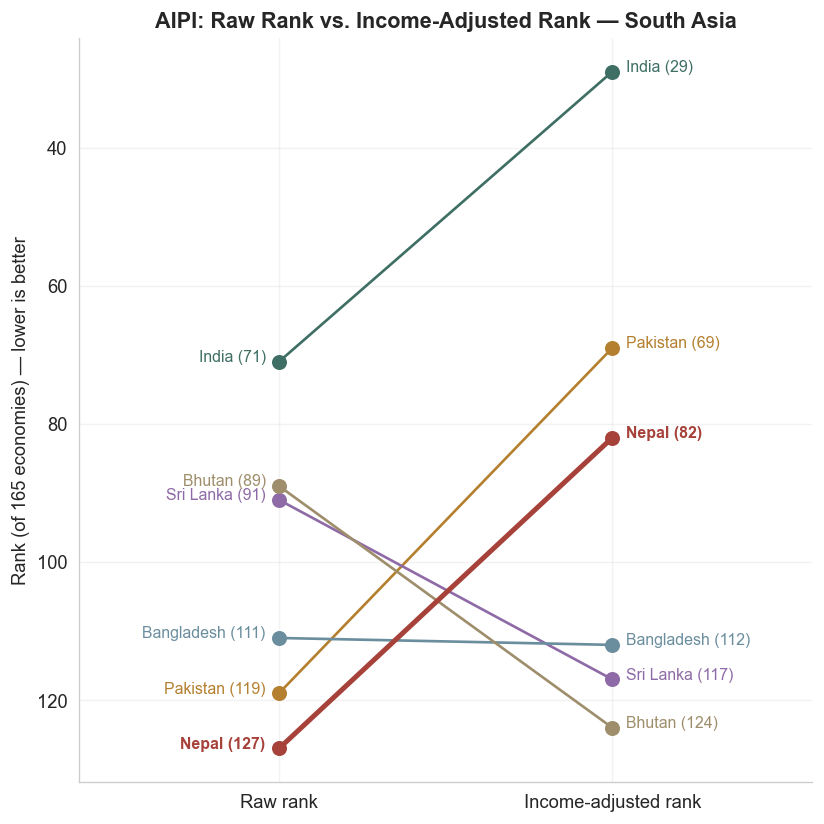

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

x_positions = [0, 1]
labels = ["Raw rank", "Income-adjusted rank"]
palette = {"NPL": "#A6423A", "IND": "#3E6E64", "PAK": "#B4802F", "BGD": "#6B8E9E", "LKA": "#8E6BA6", "BTN": "#9E8E6B"}

for _, row in df[df.iso3.isin(SOUTH_ASIA)].iterrows():
    color = palette[row.iso3]
    lw = 3 if row.iso3 == NEPAL else 1.6
    ax.plot(x_positions, [row.raw_rank, row.adjusted_rank], color=color, linewidth=lw, marker="o", markersize=8, zorder=3 if row.iso3==NEPAL else 2)
    name = NAMES[row.iso3]
    ax.annotate(f"{name} ({int(row.raw_rank)})", (x_positions[0], row.raw_rank), xytext=(-8, 0), textcoords="offset points", ha="right", fontsize=9.5, fontweight="bold" if row.iso3==NEPAL else "normal", color=color)
    ax.annotate(f"{name} ({int(row.adjusted_rank)})", (x_positions[1], row.adjusted_rank), xytext=(8, 0), textcoords="offset points", ha="left", fontsize=9.5, fontweight="bold" if row.iso3==NEPAL else "normal", color=color)

ax.set_xlim(-0.6, 1.6)
ax.invert_yaxis()
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Rank (of 165 economies) — lower is better")
ax.set_title("AIPI: Raw Rank vs. Income-Adjusted Rank — South Asia")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "aipi_raw_vs_adjusted_rank.png", bbox_inches="tight")
plt.show()